In [1]:
import os
import sys
import math
import warnings
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spisea import synthetic, evolution, atmospheres, reddening
from nbody6tools import Reader

sys.path.insert(0, "/home/wyz5rge/TurbulentClusterModel")
from nbody62spisea import converter

sys.path.insert(0, "/home/wyz5rge/synthetic-cmd-dev/cmd_generator")
import interpolator

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


In [2]:
# -----------------------------
# Simulation family for parity
# Alexandra's study: M3000, Sigma_cloud = 0.1
# -----------------------------
# BASE_LOW_DENSITY = '/storage/jfarias/Data/Orion/newbinaries/M3000sigma0.1'
BASE_LOW_DENSITY = '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial'

SIM_PATHS = {
    0.01: os.path.join(BASE_LOW_DENSITY, 'sfe_ff001') + '/00',
    0.03: os.path.join(BASE_LOW_DENSITY, 'sfe_ff003') + '/00',
    0.10: os.path.join(BASE_LOW_DENSITY, 'sfe_ff010') + '/00',
    0.30: os.path.join(BASE_LOW_DENSITY, 'sfe_ff030') + '/00',
    1.00: os.path.join(BASE_LOW_DENSITY, 'sfe_ff100') + '/00',
}

EFF_VALUES = [0.01, 0.03, 0.10, 0.30, 1.00]

# From the earlier study / your notes for M3000, Sigma=0.1
T_STAR_BY_EFF = {
    0.01: 19.40,
    0.03: 6.47,
    0.10: 1.94,
    0.30: 0.65,
    1.00: 0.19,
}

# -----------------------------
# PARSEC setup
# -----------------------------
AKs = 0.0
dist = 410
metallicity = 0.0

# Switch to PARSEC here
evo_model = evolution.Parsec()   # if this exact class name differs in your install, adjust
atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# We only need two dummy filters for the current interpolator interface.
# HR metrics use lum / Teff / logg, not the filter outputs.
filt_list = ['jwst,F115W', 'jwst,F200W']
filters = ['m_jwst_F115W', 'm_jwst_F200W']

iso_dir = 'isochrones/'

# -----------------------------
# Metric definition: parity with Alexandra
# six 100 K bins from 3000 to 3600 K
# -----------------------------
TEMP_BIN_EDGES = np.arange(3000, 3601, 100)   # 3000, 3100, ..., 3600

In [3]:
def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)
    if not sim_path.endswith('/'):
        sim_path += '/'

    snapshot = Reader.read_snapshot(sim_path, time=snapshot_time_myr)
    snapshot.to_physical()
    cluster_table = converter.to_spicea_table(snapshot)
    return cluster_table


def extract_masses_and_ages(cluster_table):
    masses = np.array(cluster_table['mass'], dtype=float)
    ages_myr = np.array(cluster_table['age'], dtype=float)
    ages_yr = ages_myr * 1e6
    return masses, ages_myr, ages_yr

In [4]:
def build_isochrone_grid(
    ages_yr,
    increment_yr=0.1e6,
    min_age_floor_yr=10**6.6,   # PARSEC minimum age in SPISEA
):
    min_age = np.min(ages_yr)
    max_age = np.max(ages_yr)

    start = max(min_age_floor_yr, math.floor(min_age / increment_yr) * increment_yr)
    end = math.ceil(max_age / increment_yr) * increment_yr + increment_yr

    level_age_arr_yr = np.arange(start, end + 0.5 * increment_yr, increment_yr)
    log_age_arr = np.log10(level_age_arr_yr)

    iso_grid = np.empty(len(log_age_arr), dtype=object)
    for i, log_age in enumerate(log_age_arr):
        iso_grid[i] = synthetic.IsochronePhot(
            log_age, AKs, dist,
            metallicity=metallicity,
            evo_model=evo_model,
            atm_func=atm_func,
            red_law=red_law,
            filters=filt_list,
            iso_dir=iso_dir
        )

    return level_age_arr_yr, log_age_arr, iso_grid

In [5]:
def safe_interpolate(age_myr, mass, iso_grid, log_age_arr, filters):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return interpolator.interpolate(age_myr, mass, iso_grid, log_age_arr, filters)
    except Exception:
        return None

In [6]:
def interpolate_snapshot_hr(cluster_table, increment_yr=0.1e6):
    masses, ages_myr, ages_yr = extract_masses_and_ages(cluster_table)
    level_age_arr_yr, log_age_arr, iso_grid = build_isochrone_grid(
        ages_yr,
        increment_yr=increment_yr
    )

    rows = []
    for m, a in zip(masses, ages_myr):
        star = safe_interpolate(a, m, iso_grid, log_age_arr, filters)
        if star is None:
            continue

        # interpolator output:
        # [lum, teff, logg, filt1, filt2]
        lum = float(star[0])
        teff = float(star[1])
        logg = float(star[2])

        if lum <= 0 or teff <= 0:
            continue

        rows.append({
            'mass': m,
            'age_myr': a,
            'lum_watts': lum,
            'lum_lsun': lum / 3.846e26,
            'logL': np.log10(lum / 3.846e26),
            'teff': teff,
            'logTeff': np.log10(teff),
            'logg': logg,
        })

    return pd.DataFrame(rows), iso_grid, level_age_arr_yr

In [7]:
def top_bottom_quartile_gap(values):
    """
    Mean(top 25%) - mean(bottom 25%)
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 4:
        return np.nan

    values = np.sort(values)
    q = max(1, len(values) // 4)

    bottom = values[:q]
    top = values[-q:]

    return np.mean(top) - np.mean(bottom)


def compute_hr_metrics(df_hr, cluster_table, temp_bin_edges=TEMP_BIN_EDGES):
    """
    Returns:
      sigma_L : mean quartile-gap luminosity spread across temperature bins
      mu_L    : mean of mean luminosities across temperature bins
      dt90    : 95th percentile age - 5th percentile age, from the RAW cluster ages
    """
    # ---- compute sigma_L and mu_L from interpolated HR catalog ----
    bin_spreads = []
    bin_means = []
    bin_counts = []

    if len(df_hr) > 0 and 'teff' in df_hr.columns:
        for t_lo, t_hi in zip(temp_bin_edges[:-1], temp_bin_edges[1:]):
            sub = df_hr[(df_hr['teff'] >= t_lo) & (df_hr['teff'] < t_hi)]

            if len(sub) < 4:
                continue

            lum_vals = sub['logL'].values
            spread = top_bottom_quartile_gap(lum_vals)
            mean_lum = np.mean(lum_vals)

            if np.isfinite(spread):
                bin_spreads.append(spread)
                bin_means.append(mean_lum)
                bin_counts.append(len(sub))

    sigma_L = np.mean(bin_spreads) if len(bin_spreads) > 0 else np.nan
    mu_L = np.mean(bin_means) if len(bin_means) > 0 else np.nan

    # ---- compute dt90 from raw cluster ages, not interpolated subset ----
    _, ages_myr_raw, _ = extract_masses_and_ages(cluster_table)
    if len(ages_myr_raw) >= 2:
        dt90 = np.percentile(ages_myr_raw, 95) - np.percentile(ages_myr_raw, 5)
    else:
        dt90 = np.nan

    return {
        'sigma_L': sigma_L,
        'mu_L': mu_L,
        'dt90': dt90,
        'bin_spreads': np.array(bin_spreads),
        'bin_means': np.array(bin_means),
        'bin_counts': np.array(bin_counts),
    }

In [8]:
test_eff = 0.03
test_time = 10.0

cluster_table = load_cluster_table(SIM_PATHS[test_eff], test_time)
df_hr, iso_grid, level_age_arr_yr = interpolate_snapshot_hr(cluster_table)

metrics = compute_hr_metrics(df_hr, cluster_table)

print(f"N raw stars: {len(cluster_table)}")
print(f"N interpolated stars: {len(df_hr)}")
print(metrics)

Changing to T=  7000 for T=  7029 logg=3.88
Changing to T=  7000 for T=  7036 logg=3.88
Changing to T=  7000 for T=  7165 logg=3.89
Changing to T=  7000 for T=  7391 logg=3.92
Changing to T=  7000 for T=  7630 logg=3.95
Changing to T=  7000 for T=  7880 logg=3.99
Changing to T=  7000 for T=  7900 logg=3.99
Changing to T=  7000 for T=  8022 logg=4.01
Changing to T=  7000 for T=  8281 logg=4.08
Changing to T=  7000 for T=  8348 logg=4.12
Changing to T=  7000 for T=  8341 logg=4.15
Changing to T=  7000 for T=  8306 logg=4.17
Changing to T=  7000 for T=  8268 logg=4.19
Changing to T=  7000 for T=  8264 logg=4.20
Changing to T=  7000 for T=  8283 logg=4.22
Changing to T=  7000 for T=  8385 logg=4.22
Changing to T=  7000 for T=  8752 logg=4.22
Changing to T=  7000 for T=  8790 logg=4.22
Changing to T=  7000 for T=  8956 logg=4.23
Changing to T=  7000 for T=  9373 logg=4.25
Changing to T=  7000 for T=  9423 logg=4.25
Changing to T=  7000 for T=  9465 logg=4.25
Changing to T=  7000 for T=  982

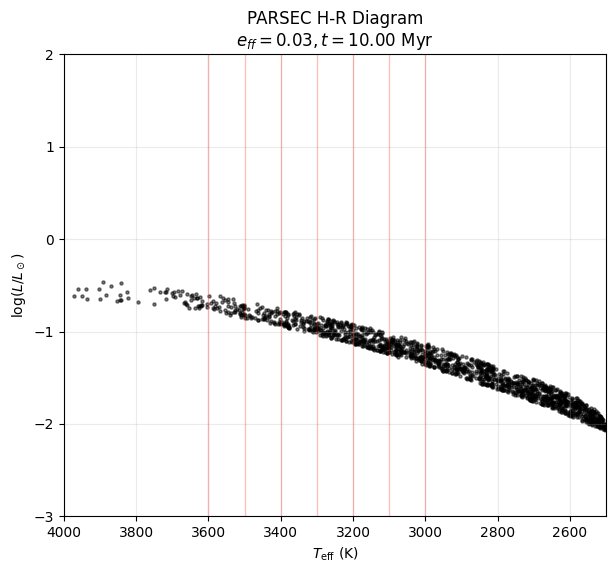

In [9]:
plt.figure(figsize=(7, 6))

# isochrone grid
cmap = plt.get_cmap('coolwarm')
for i, iso in enumerate(iso_grid):
    frac = i / max(len(iso_grid) - 1, 1)
    color = cmap(frac)

    teff = np.array(iso.points['Teff'], dtype=float)
    lum = np.array(iso.points['L'], dtype=float) / 3.846e26
    good = (teff > 0) & (lum > 0)

    # plt.plot(teff[good], np.log10(lum[good]), color=color, alpha=0.7, lw=1.0)

# stars
plt.scatter(df_hr['teff'], df_hr['logL'], s=5, alpha=0.5, color='k')

# temp bins
for t in TEMP_BIN_EDGES:
    plt.axvline(t, color='red', alpha=0.25, lw=1)

plt.xlim(2500, 4000)
plt.ylim(-3, 2)
    
plt.xlabel(r'$T_{\mathrm{eff}}$ (K)')
plt.ylabel(r'$\log(L/L_\odot)$')
plt.title(f'PARSEC H-R Diagram\n$e_{{ff}}={test_eff}, t={test_time:.2f}$ Myr')
plt.gca().invert_xaxis()
plt.grid(alpha=0.25)
plt.show()

In [10]:
def build_hr_time_series(sim_path, snapshot_times_myr, eff_label):
    rows = []

    for t in snapshot_times_myr:
        try:
            cluster_table = load_cluster_table(sim_path, t)
            df_hr, _, _ = interpolate_snapshot_hr(cluster_table)
            metrics = compute_hr_metrics(df_hr, cluster_table)

            rows.append({
                'eff': eff_label,
                't_myr': t,
                'dt90': metrics['dt90'],
                'sigma_L': metrics['sigma_L'],
                'mu_L': metrics['mu_L'],
                'n_stars_interp': len(df_hr),
                'n_stars_raw': len(cluster_table),
            })

            print(f"e_ff={eff_label:.2f}, t={t:.2f} done")
        except Exception as e:
            print(f"e_ff={eff_label:.2f}, t={t:.2f} failed: {e}")

    return pd.DataFrame(rows)

In [11]:
all_dfs = []

for eff in EFF_VALUES:
    t_star = T_STAR_BY_EFF[eff]

    # sample beyond the formation time so dt90 can plateau
    if eff == 0.01:
        times = np.arange(0.5, 22.1, 0.5)
    elif eff == 0.03:
        times = np.arange(0.5, 8.1, 0.25)
    elif eff == 0.10:
        times = np.arange(0.25, 3.1, 0.1)
    elif eff == 0.30:
        times = np.arange(0.10, 1.3, 0.05)
    elif eff == 1.00:
        times = np.arange(0.05, 0.6, 0.02)

    df_eff = build_hr_time_series(SIM_PATHS[eff], times, eff)
    all_dfs.append(df_eff)

df_all = pd.concat(all_dfs, ignore_index=True)
df_all.head()

e_ff=0.01, t=0.50 done
e_ff=0.01, t=1.00 done
e_ff=0.01, t=1.50 done
e_ff=0.01, t=2.00 done
e_ff=0.01, t=2.50 done
e_ff=0.01, t=3.00 done
e_ff=0.01, t=3.50 done
e_ff=0.01, t=4.00 done
e_ff=0.01, t=4.50 done
e_ff=0.01, t=5.00 done
e_ff=0.01, t=5.50 done
e_ff=0.01, t=6.00 done
e_ff=0.01, t=6.50 done
e_ff=0.01, t=7.00 done
e_ff=0.01, t=7.50 done
e_ff=0.01, t=8.00 done
e_ff=0.01, t=8.50 done
e_ff=0.01, t=9.00 done
e_ff=0.01, t=9.50 done
e_ff=0.01, t=10.00 done
Changing to T=  7000 for T=  7036 logg=4.03
Changing to T=  7000 for T=  7249 logg=4.08
Changing to T=  7000 for T=  7251 logg=4.08
Changing to T=  7000 for T=  7338 logg=4.11
Changing to T=  7000 for T=  7376 logg=4.15
Changing to T=  7000 for T=  7367 logg=4.18
Changing to T=  7000 for T=  7354 logg=4.19
Changing to T=  7000 for T=  7338 logg=4.21
Changing to T=  7000 for T=  7345 logg=4.23
Changing to T=  7000 for T=  7364 logg=4.23
Changing to T=  7000 for T=  7369 logg=4.23
Changing to T=  7000 for T=  7619 logg=4.22
Changing to

/home/wyz5rge/TurbulentClusterModel/nbody62spisea/converter.py:236: RuntimeWarning: divide by zero encountered in log10
  log_a = numpy.concatenate( [numpy.full(len(singles),numpy.nan), numpy.log10(bdict['semi']) ] )


Changing to T=  7000 for T=  7036 logg=4.28
Changing to T=  7000 for T=  7183 logg=4.28
Changing to T=  7000 for T=  7183 logg=4.28
Changing to T=  7000 for T=  7504 logg=4.30
Changing to T=  7000 for T=  7514 logg=4.30
Changing to T=  7000 for T=  7768 logg=4.32
Changing to T=  7000 for T=  7958 logg=4.33
Changing to T=  7000 for T=  8008 logg=4.33
Changing to T=  7000 for T=  8234 logg=4.34
Changing to T=  7000 for T=  8451 logg=4.34
Changing to T=  7000 for T=  8664 logg=4.35
Changing to T=  7000 for T=  8867 logg=4.35
Changing to T=  7000 for T=  9068 logg=4.35
Changing to T=  7000 for T=  9264 logg=4.36
Changing to T=  7000 for T=  9454 logg=4.36
Changing to T=  7000 for T=  9638 logg=4.36
Changing to T=  7000 for T=  9820 logg=4.36
Changing to T=  7000 for T=  9998 logg=4.36
Changing to T=  7000 for T= 10177 logg=4.36
Changing to T=  7000 for T= 10347 logg=4.36
Changing to T=  7000 for T= 10517 logg=4.36
Changing to T=  7000 for T= 10844 logg=4.36
Changing to T=  7000 for T= 1146

,eff,t_myr,dt90,sigma_L,mu_L,n_stars_interp,n_stars_raw
0,0.01,0.5,0.435161,NaN,NaN,0,182
1,0.01,1.0,0.910852,NaN,NaN,0,273
2,0.01,1.5,1.442299,NaN,NaN,0,389
3,0.01,2.0,1.891675,NaN,NaN,0,465
4,0.01,2.5,2.319254,NaN,NaN,0,570


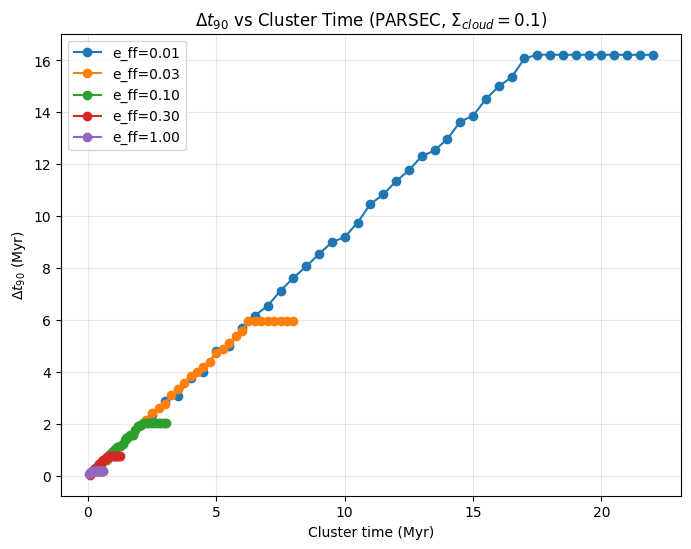

In [12]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['dt90'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel('Cluster time (Myr)')
plt.ylabel(r'$\Delta t_{90}$ (Myr)')
plt.title(r'$\Delta t_{90}$ vs Cluster Time (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

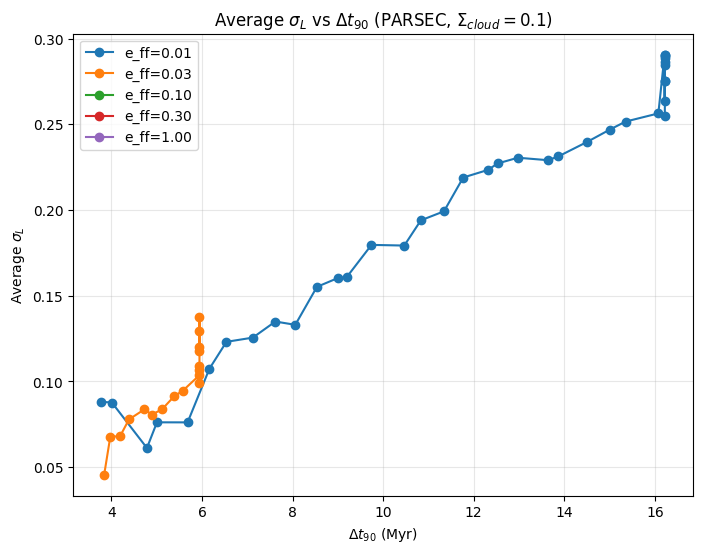

In [13]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('dt90')
    plt.plot(sub['dt90'], sub['sigma_L'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel(r'$\Delta t_{90}$ (Myr)')
plt.ylabel(r'Average $\sigma_L$')
plt.title(r'Average $\sigma_L$ vs $\Delta t_{90}$ (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

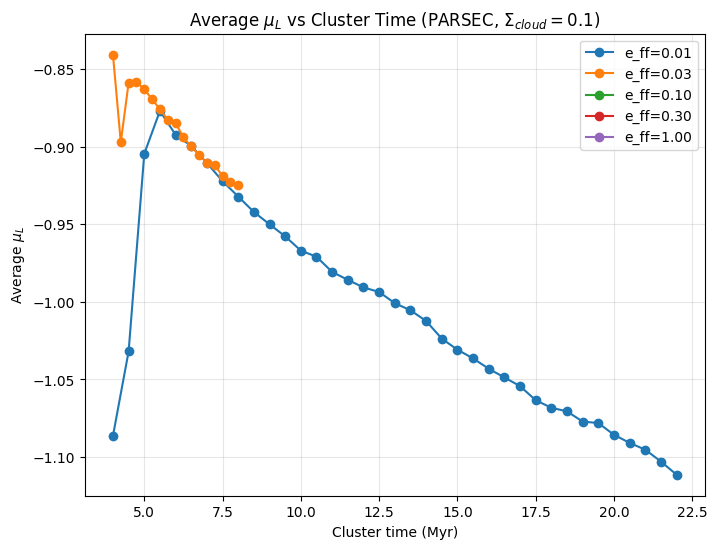

In [14]:
plt.figure(figsize=(8, 6))

for eff in EFF_VALUES:
    sub = df_all[df_all['eff'] == eff].sort_values('t_myr')
    plt.plot(sub['t_myr'], sub['mu_L'], marker='o', label=f'e_ff={eff:.2f}')

plt.xlabel('Cluster time (Myr)')
plt.ylabel(r'Average $\mu_L$')
plt.title(r'Average $\mu_L$ vs Cluster Time (PARSEC, $\Sigma_{cloud}=0.1$)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [15]:
summary = (
    df_all.groupby('eff')[['dt90', 'sigma_L', 'mu_L', 'n_stars_interp', 'n_stars_raw']]
    .agg(['min', 'max', 'mean'])
)

summary

dt90                         sigma_L                          mu_L  \
           min        max       mean       min       max      mean       min   
eff                                                                            
0.01  0.435161  16.221128  10.024316  0.061153  0.290591  0.199869 -1.111439   
0.03  0.417859   5.945576   3.792946  0.045557  0.137449  0.095061 -0.924667   
0.10  0.222720   2.042984   1.413109       NaN       NaN       NaN       NaN   
0.30  0.032191   0.747079   0.544748       NaN       NaN       NaN       NaN   
1.00  0.041406   0.162530   0.148205       NaN       NaN       NaN       NaN   

                         n_stars_interp                   n_stars_raw        \
           max      mean            min   max        mean         min   max   
eff                                                                           
0.01 -0.876844 -1.007930              0  1962  881.000000         182  3027   
0.03 -0.840604 -0.889236              0  1232  351.322581         328  2910   
0.10       NaN       NaN              0     0    0.000000         388  2582   
0.30       NaN       NaN              0     0    0.000000         271  2515   
1.00       NaN       NaN              0     0    0.000000         675  2393   

                   
             mean  
eff                
0.01  1895.613636  
0.03  1901.387097  
0.10  1830.862069  
0.30  1747.083333  
1.00  2176.607143